# 09 · Results & recommendation (Parts 14–16)

Assembles the presentation set — **Tables 1–5**, **Charts A–F** — and states the
economic interpretation and the actionable pricing rule. Reads only the saved
outputs of notebooks 03–08; runs no new estimation.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SRC = Path.cwd().parent / "src"
sys.path.insert(0, str(SRC))
import config as C
from common import AuditLog

LOG = AuditLog("09_results")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": C.PLOT_DPI, "font.size": 9,
                     "axes.grid": True, "grid.alpha": .3, "axes.axisbelow": True})
T = C.OUT_TAB
df = pd.read_parquet(C.P_ANALYSIS)

## Chart A — "Argentina's inflation made hotel pricing a moving target"

Real 4★ rate (what a peso of list price actually bought), rebased to 100 at
2017-01, against the flat line a perfect CPI-indexation would have held. The
gap is the swing hotels actually rode: a pre-devaluation real overshoot then a
25–30% real erosion through 2024–25.

  [09_results] figure                 09_chartA_moving_target.png                


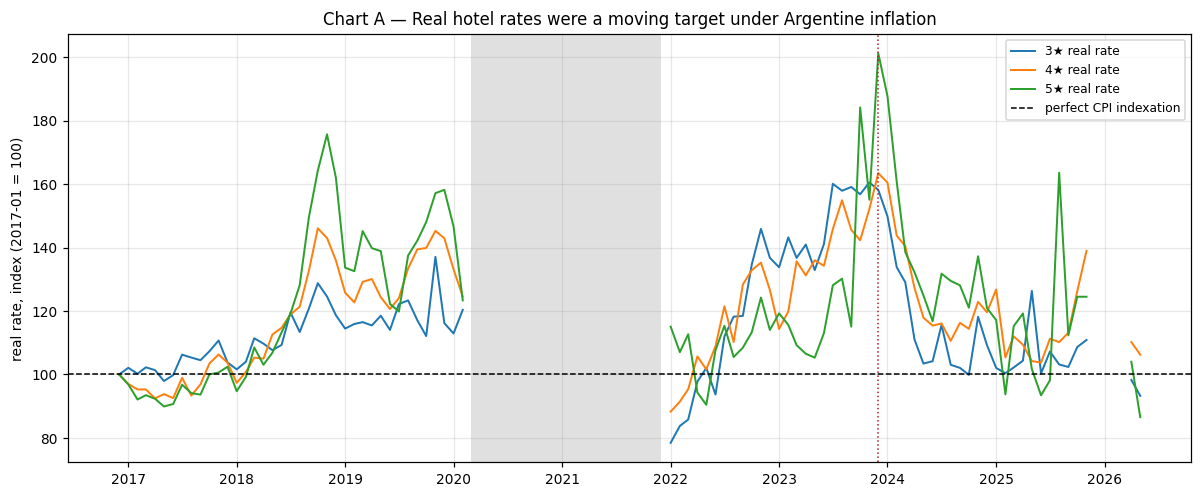

  [09_results] real_rate_cv           coeff. of variation of real rate (%)           {'apart': 17.7, 'boutique': 16.5, 'stars_1_2': 9.4, 'stars_3': 15.9, 'stars_4': 14.8, 'stars_5': 20.1}


hotel_category
apart        17.7
boutique     16.5
stars_1_2     9.4
stars_3      15.9
stars_4      14.8
stars_5      20.1
Name: real_rate_gba, dtype: float64

In [2]:
W = df[(df.in_window == 1)].copy()
fig, ax = plt.subplots(figsize=(11, 4.6))
full = pd.date_range(W.date.min(), W.date.max(), freq="MS")
for cat, lab in [("stars_3", "3★"), ("stars_4", "4★"), ("stars_5", "5★")]:
    s = (W[W.hotel_category == cat].set_index("date")["real_rate_gba"]
         .reindex(full))                      # NaN months -> line breaks, no interpolation
    base = s.dropna().iloc[0]
    ax.plot(full, s / base * 100, lw=1.3, label=f"{lab} real rate")
ax.axhline(100, color="k", lw=1, ls="--", label="perfect CPI indexation")
ax.axvspan(pd.Timestamp(C.COVID_HOLE_START), pd.Timestamp(C.COVID_HOLE_END),
           color="0.6", alpha=.3, lw=0)
ax.axvline(pd.Timestamp("2023-12-01"), color="firebrick", lw=1, ls=":")
ax.annotate("Dec-2023\ndevaluation", (pd.Timestamp("2023-12-01"), 60),
            color="firebrick", fontsize=8, ha="center")
ax.set_ylabel("real rate, index (2017-01 = 100)")
ax.set_title("Chart A — Real hotel rates were a moving target under Argentine inflation")
ax.legend(fontsize=8)
fig.tight_layout(); fig.savefig(C.OUT_FIG / "09_chartA_moving_target.png")
LOG.log("figure", "09_chartA_moving_target.png"); plt.show()

# real-rate volatility: observed vs indexed
vol = (W[W.hotel_category.isin(C.MODEL_CATEGORIES) & (W.covid_hole == 0)]
       .groupby("hotel_category")["real_rate_gba"]
       .apply(lambda s: s.std() / s.mean() * 100).round(1))
LOG.log("real_rate_cv", "coeff. of variation of real rate (%)", detail=vol.to_dict())
vol

## Tables 1–5 (consolidated view)

In [3]:
print("TABLE 1 — descriptive statistics by category")
tab1 = pd.read_csv(T / "table1_descriptives.csv", index_col=0)
tab1

TABLE 1 — descriptive statistics by category


,label,n_months,nominal_rate_mean,real_rate_gba_mean,real_rate_gba_sd,real_rate_cagr_pct,room_occ_mean,room_occ_sd,bed_occ_mean,rate_mom_mean_pct,rate_mom_sd_pct,cpi_mom_mean_pct,share_months_rate_gt_cpi,share_months_rate_up
hotel_category,,,,,,,,,,,,,,
apart,Apart-hotel,92,33256.333,1124.324,198.725,-0.528,60.753,7.527,42.312,5.612,11.808,4.631,0.489,0.772
boutique,Boutique,92,55328.781,1934.081,318.239,1.759,66.344,7.066,54.425,5.335,8.639,4.631,0.543,0.739
stars_1_2,1-2 star,92,17645.014,558.192,52.646,1.707,47.508,8.079,40.716,4.406,7.944,4.631,0.402,0.641
stars_3,3 star,92,21134.575,769.722,122.453,-0.904,61.374,7.740,48.943,5.670,8.881,4.631,0.467,0.707
stars_4,4 star,92,34137.888,1194.647,176.731,0.793,64.717,8.116,51.708,5.552,7.957,4.631,0.478,0.728
stars_5,5 star,92,87870.194,3085.302,618.710,-1.868,62.911,9.619,45.675,5.627,15.492,4.631,0.446,0.609


In [4]:
print("TABLE 2 — inflation pass-through (Δln rate on Δln CPI, HAC SE)")
tab2 = pd.read_csv(T / "table2_passthrough.csv")
tab2[tab2["sample"] == "covid_excl"].set_index("hotel_category")[
    ["label", "beta_contemp", "se_contemp", "t_contemp", "beta_cum_0_3", "r2", "n"]]

TABLE 2 — inflation pass-through (Δln rate on Δln CPI, HAC SE)


,label,beta_contemp,se_contemp,t_contemp,beta_cum_0_3,r2,n
hotel_category,,,,,,,
apart,Apart-hotel,0.893,0.146,6.13,0.771,0.108,76
boutique,Boutique,1.159,0.199,5.81,0.856,0.304,76
stars_1_2,1-2 star,0.854,0.125,6.85,0.784,0.183,75
stars_3,3 star,0.747,0.138,5.41,0.594,0.142,76
stars_4,4 star,1.085,0.160,6.77,0.800,0.332,76
stars_5,5 star,1.251,0.278,4.51,0.881,0.121,76


In [5]:
print("TABLE 3 — elasticity of occupancy w.r.t. real rate (naive) + identification (06b)")
tab3 = pd.read_csv(T / "table3_elasticity.csv")
ident = pd.read_csv(T / "identification_summary.csv")
display(tab3[tab3.spec == "loglog"].set_index("label")[["beta", "t", "n"]])
ident[ident.strategy.isin(["B_relative_price_FE", "C_2sls_cost_iv"])][
    ["strategy", "label", "beta", "t", "fstage_F"]]

TABLE 3 — elasticity of occupancy w.r.t. real rate (naive) + identification (06b)


,beta,t,n
label,,,
1-2 star,0.997,5.72,77
3 star,0.323,2.37,77
4 star,0.010,0.11,77
5 star,-0.033,-0.49,77
Apart-hotel,0.056,0.52,77
Boutique,0.112,1.44,77


,strategy,label,beta,t,fstage_F
6,B_relative_price_FE,4 star tiers,0.069,1.13,NaN
7,C_2sls_cost_iv,1-2 star,0.899,1.61,6.8
8,C_2sls_cost_iv,3 star,-0.868,-1.03,2.9
9,C_2sls_cost_iv,4 star,-0.262,-2.70,140.0
10,C_2sls_cost_iv,5 star,-0.074,-0.95,106.5
11,C_2sls_cost_iv,Apart-hotel,-0.601,-2.59,20.1
12,C_2sls_cost_iv,Boutique,0.018,0.24,206.7


In [6]:
print("TABLE 4 — repricing-rule comparison, test window, matched real price")
tab4 = pd.read_csv(T / "table4_policy_comparison.csv")
tab4.pivot_table(index="label", columns="rule",
                 values=["real_P_vol_pct", "worst_erosion_pct", "n_price_changes"]).round(1)

TABLE 4 — repricing-rule comparison, test window, matched real price


n_price_changes                                             \
rule             A_full_cpi C_partial D_infl_plus_occ R_infl_threshold   
label                                                                    
1-2 star               36.0      37.0            21.0             29.0   
3 star                 36.0      37.0            24.0             29.0   
4 star                 36.0      37.0            24.0             29.0   
5 star                 36.0      37.0            24.0             29.0   
Apart-hotel            36.0      37.0            24.0             29.0   
Boutique               36.0      37.0            24.0             29.0   

                                       real_P_vol_pct            \
rule        R_realprice_floor baseline     A_full_cpi C_partial   
label                                                             
1-2 star                 33.0     37.0            4.9      28.0   
3 star                   31.0     37.0            5.7      28.0   
4 star                   34.0     37.0            4.9      28.0   
5 star                   34.0     37.0            5.0      28.0   
Apart-hotel              32.0     37.0            5.3      28.0   
Boutique                 32.0     37.0            5.7      28.0   

                                                                         \
rule        D_infl_plus_occ R_infl_threshold R_realprice_floor baseline   
label                                                                     
1-2 star                4.5              4.7               4.8     11.8   
3 star                  6.1              5.8               5.9     18.7   
4 star                  4.7              5.0               4.7     13.3   
5 star                  5.5              5.2               4.8     20.4   
Apart-hotel             5.5              5.2               5.3     15.3   
Boutique                5.9              5.8               5.8     13.4   

            worst_erosion_pct                                             \
rule               A_full_cpi C_partial D_infl_plus_occ R_infl_threshold   
label                                                                      
1-2 star                -15.4     -43.4           -11.2            -15.0   
3 star                  -15.6     -43.4           -13.4            -15.5   
4 star                  -15.0     -43.4           -11.7            -14.3   
5 star                  -15.0     -43.4           -14.0            -14.2   
Apart-hotel             -15.5     -43.4           -14.8            -15.3   
Boutique                -15.6     -43.4           -14.7            -15.5   

                                        
rule        R_realprice_floor baseline  
label                                   
1-2 star                -15.3    -22.6  
3 star                  -15.9    -29.0  
4 star                  -14.9    -17.4  
5 star                  -14.9    -31.3  
Apart-hotel             -15.6    -31.4  
Boutique                -15.9    -19.1

In [7]:
print("TABLE 5 — out-of-sample RevPAR vs observed, by assumed β (matched real price)")
tab5 = pd.read_csv(T / "table5_out_of_sample.csv")
tab5.pivot_table(index=["label"], columns=["rule", "beta"], values="revpar_vs_obs_pct").round(1)

TABLE 5 — out-of-sample RevPAR vs observed, by assumed β (matched real price)


rule        A_full_cpi            C_partial             D_infl_plus_occ       \
beta              -1.0 -0.5  -0.1      -1.0  -0.5  -0.1            -1.0 -0.5   
label                                                                          
1-2 star           0.0 -1.1  -1.7       0.0   3.1   7.3             0.0 -1.7   
3 star             0.0  2.8   5.7       0.0   8.4  18.2             0.0  2.8   
4 star             0.0  4.6   8.9       0.0  10.2  21.0             0.0  4.8   
5 star             0.0  6.5  12.9       0.0  12.5  26.1             0.0  6.7   
Apart-hotel        0.0 -3.2  -5.2       0.0   1.2   4.2             0.0 -4.2   
Boutique           0.0  4.0   7.8       0.0   9.8  20.3             0.0  3.9   

rule              R_infl_threshold            R_realprice_floor             \
beta         -0.1             -1.0 -0.5  -0.1              -1.0 -0.5  -0.1   
label                                                                        
1-2 star     -2.9              0.0 -1.7  -2.6               0.0 -1.6  -2.5   
3 star        5.8              0.0  2.8   5.8               0.0  2.9   5.9   
4 star        9.3              0.0  4.8   9.3               0.0  4.8   9.3   
5 star       13.4              0.0  7.0  13.8               0.0  6.9  13.7   
Apart-hotel  -7.0              0.0 -4.1  -6.8               0.0 -4.0  -6.6   
Boutique      7.6              0.0  4.0   7.8               0.0  4.1   7.9   

rule        baseline             
beta            -1.0 -0.5  -0.1  
label                            
1-2 star         0.0 -2.8  -5.0  
3 star           0.0 -1.1  -2.0  
4 star           0.0  2.3   4.2  
5 star           0.0  5.3   9.7  
Apart-hotel      0.0 -6.9 -12.1  
Boutique         0.0  2.0   3.6

## Part 14 — economic interpretation

**1. Does higher inflation make hotels adjust prices more frequently?**
Not on this measure — the reported *average* rate moves essentially every month
in every regime (freq ≈ 1). What changes with inflation is the **size and
direction**: in the top inflation tercile (CPI ≈ 8.8% m/m) the mean absolute
monthly rate change is **9.6%** vs **6.3%** in the low tercile, and **83%** of
moves are increases vs **64%**. Bigger and more one-directional, not more often.

**2. Do hotel rates keep up with inflation?** On average yes, in bursts. Real
rates have **~0% trend** over 2017–2026 (Table 1 CAGR −1.9%…+1.8%), but only
**40–54%** of months see the rate beat CPI — catch-up is lumpy, concentrated
around devaluation episodes, with real erosion in between (Chart B).

**3. Which categories pass through fastest?** Upper tiers. Contemporaneous
pass-through β: **5★ 1.25, boutique 1.16, 4★ 1.09** (full or slightly over) vs
**3★ 0.75** (slowest) and **1–2★ 0.85**. Pass-through is identified almost
entirely off the high-inflation episodes; strip them and β is not estimable.

**4. How sensitive is occupancy to real rates?** Weakly, at most. The naive
regression gives a *positive* slope (endogeneity: hotels price into demand).
The identification attempts that break that (relative-price panel with month
FE ≈ 0; 2SLS with strong first stage) put the elasticity between **0 and −0.6**
— 4★ ≈ −0.26, apart ≈ −0.6, 5★/boutique ≈ 0. Demand is **inelastic**; 1–2★ and
3★ could not be identified.

**5. Does the demand response differ by category?** Within the inelastic range,
apart-hotels look the most price-sensitive (−0.6) and 5★/boutique the least
(~0). But confidence intervals overlap; treat as "all fairly inelastic".

**6. Does full pass-through maximise revenue?** With inelastic demand and **no
cost data**, the constant-elasticity revenue function is monotone in price — the
"optimal" pass-through pins to whatever ceiling you impose (nb07 §1). So the
question is ill-posed without marginal cost; we optimise *tracking*, not a point.

**7. Is partial pass-through better?** No. Any k < 1 lets the real price
compound-erode in a high-inflation regime; k must be ≈ 1 (full) or slightly
above. A *fixed* partial coefficient (k = 1.4 chosen on 2022) over-shoots
out-of-sample — it does not travel across inflation regimes (Chart F).

**8. How does the optimal policy change between high- and low-inflation
periods?** In low inflation, monthly repricing is cheap and a simple CPI reset
suffices. As inflation accelerates, a **cumulative-inflation trigger** (reprice
when CPI has risen ≥ ~5% since the last change) holds the real price about as
well as monthly repricing (real-price CV ~5% vs ~13% for observed pricing) with
**~35% fewer price changes**; letting the trigger exceed ~12% starts to cost
real value (worst-case erosion jumps past −20%).

**9. How much could a dynamic policy add over mechanical indexing?** Little on
revenue. At matched real-price level and β ≈ −0.5, the threshold rule and the
threshold-plus-occupancy-tilt rule land within **1–2 pp of RevPAR** of a plain
monthly CPI reset. The gain over *observed* pricing is **+3 to +13% RevPAR**
for 4★/5★/boutique — and that is mostly from not letting the real price drift,
not from clever dynamics.

## Recommended pricing rule (estimated from the data, not assumed)

> **Set a real-rate target from your pre-shock competitive position. Re-index
> list prices to CPI whenever cumulative CPI inflation since your last change
> exceeds ~5% (≈ monthly when inflation runs >5%/mo; every 2–3 months at
> 2%/mo). At each re-index, tilt +/−3–6% by whether trailing-quarter occupancy
> is running above or below its seasonal norm. Do not use a fixed partial
> pass-through coefficient below 1 — in a high-inflation regime it guarantees
> real-price erosion. Upper-tier hotels (4–5★, boutique) can and do pass
> through fully or slightly over; 3★ is the segment that historically lagged
> and lost the most real value.**

Thresholds (~5% cumulative-inflation trigger, ±3–6% occupancy tilt, target from
2019 real rates) are the validation-selected values; re-fit them as data extends.

In [8]:
LOG.flush()
print("09 complete — presentation set in outputs/figures + outputs/tables.")

09 complete — presentation set in outputs/figures + outputs/tables.
